In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

2026-01-14 12:57:45.388139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768395465.554822      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768395465.602749      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768395465.990098      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768395465.990141      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768395465.990144      55 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [3]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)

In [4]:
valid_gen = ImageDataGenerator(rescale=1./255)

In [5]:
train_data = train_gen.flow_from_directory(
    "/kaggle/input/dogsvscats/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 20000 images belonging to 2 classes.


In [6]:
val_data = valid_gen.flow_from_directory(
    "/kaggle/input/dogsvscats/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 5000 images belonging to 2 classes.


In [7]:
NUM_CLASSES = train_data.num_classes

In [8]:
vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1768395488.971016      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768395488.974847      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
for layer in vgg16_base.layers:
    layer.trainable = False   # Freeze pretrained layers

In [10]:
x = Flatten()(vgg16_base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

In [11]:
vgg16_model = Model(vgg16_base.input, output)

In [12]:
vgg16_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [13]:
history_vgg16 = vgg16_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1768395493.609919     138 service.cc:152] XLA service 0x7bf21400d0e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768395493.609954     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768395493.609958     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768395494.091766     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/625 ━━━━━━━━━━━━━━━━━━━━ 2:29:14 14s/step - accuracy: 0.4375 - loss: 1.1288

I0000 00:00:1768395506.221593     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 492ms/step - accuracy: 0.8250 - loss: 0.4940 - val_accuracy: 0.9000 - val_loss: 0.2257
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 412ms/step - accuracy: 0.8873 - loss: 0.2630 - val_accuracy: 0.9352 - val_loss: 0.1580
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 408ms/step - accuracy: 0.9042 - loss: 0.2289 - val_accuracy: 0.9372 - val_loss: 0.1547
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - accuracy: 0.9050 - loss: 0.2232 - val_accuracy: 0.9374 - val_loss: 0.1551
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 395ms/step - accuracy: 0.9114 - loss: 0.2102 - val_accuracy: 0.9424 - val_loss: 0.1408
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 406ms/step - accuracy: 0.9158 - loss: 0.2041 - val_accuracy: 0.9384 - val_loss: 0.1408
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - accuracy: 0.9210 - loss: 0.1883 - val_accuracy: 0.9378 - val_loss: 0.1480
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 252s 403ms/step - accuracy: 0.9228 - loss: 0.18

In [15]:
vgg16_model.save('/kaggle/working/vgg16_model.keras')

In [16]:
vgg19_base = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
for layer in vgg19_base.layers:
    layer.trainable = False

In [23]:
x = Flatten()(vgg19_base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

In [24]:
vgg19_model = Model(vgg19_base.input, output)

In [25]:
vgg19_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [26]:
history_vgg19 = vgg19_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 289s 458ms/step - accuracy: 0.7972 - loss: 0.5893 - val_accuracy: 0.9084 - val_loss: 0.2233
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 267s 426ms/step - accuracy: 0.8559 - loss: 0.3180 - val_accuracy: 0.9122 - val_loss: 0.2067
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 276s 442ms/step - accuracy: 0.8736 - loss: 0.2863 - val_accuracy: 0.9208 - val_loss: 0.1893
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 284s 454ms/step - accuracy: 0.8872 - loss: 0.2611 - val_accuracy: 0.9204 - val_loss: 0.1970
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 285s 455ms/step - accuracy: 0.8727 - loss: 0.2845 - val_accuracy: 0.9238 - val_loss: 0.1778
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 283s 453ms/step - accuracy: 0.8941 - loss: 0.2489 - val_accuracy: 0.9248 - val_loss: 0.1763
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 272s 435ms/step - accuracy: 0.8958 - loss: 0.2383 - val_accuracy: 0.9264 - val_loss: 0.1775
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 440ms/step - accuracy: 0.8985 -

In [27]:
vgg19_model.save('/kaggle/working/vgg19_model.keras')

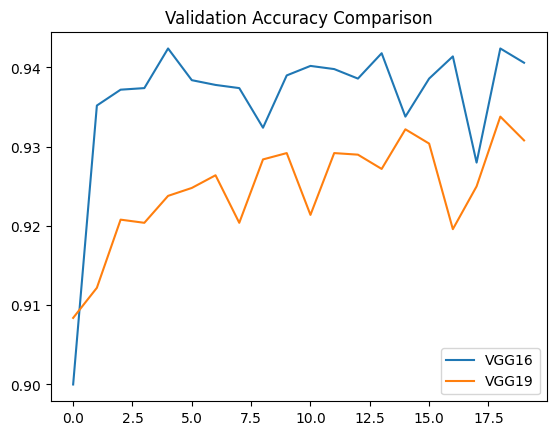

In [28]:
plt.plot(history_vgg16.history['val_accuracy'], label="VGG16")
plt.plot(history_vgg19.history['val_accuracy'], label="VGG19")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()

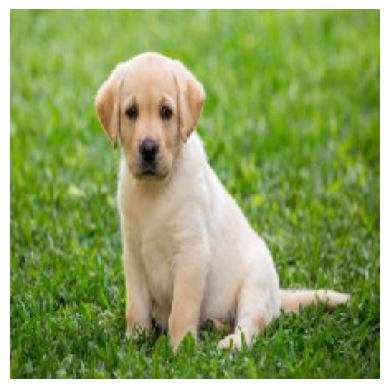

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Class: {'cats': 0, 'dogs': 1}


In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("/kaggle/input/vgg-pred-anim/vgg-pred-anim-a.jpg", target_size=(224,224))
img = image.img_to_array(img)/255

plt.imshow(img)  # Normalize the pixel values
plt.axis('off')  # Turn off axis numbers and ticks
plt.show()

img = np.expand_dims(img, axis=0)

pred = vgg19_model.predict(img)
print("Predicted Class:", train_data.class_indices)

